# Feature Extraction Walkthrough

This notebook demonstrates how raw compactor telemetry is transformed into model-ready features for fill-level inference.

## 1. Load a Sample Record

We'll load a single record from `clean_waveform_benchmark/clean_waveform_dataset.json`.

In [2]:
import json
from pathlib import Path

# Load the dataset
with open(Path("../clean_waveform_benchmark/clean_waveform_dataset.json")) as f:
    data = json.load(f)

# Select the record with record_id == 'apartment_empty__v001'
sample = next(r for r in data["records"] if r["record_id"] == "apartment_empty__v001")
print("Sample record ID:", sample["record_id"])
print("Labels:", sample["labels"])

# Print all keys and types for debugging
print("Top-level keys:", list(sample.keys()))
for k, v in sample.items():
    print(f"{k}: type={type(v)}, example={str(v)[:120]}")

# Try to find a waveform-like key
waveform = None
for key in sample.keys():
    if isinstance(sample[key], list) and all(isinstance(x, (int, float)) for x in sample[key][:5]):
        waveform = sample[key]
        print(f"Found waveform in key: {key}")
        break
    if isinstance(sample[key], dict):
        for subkey in sample[key]:
            if isinstance(sample[key][subkey], list) and all(isinstance(x, (int, float)) for x in sample[key][subkey][:5]):
                waveform = sample[key][subkey]
                print(f"Found waveform in nested key: {key}['{subkey}']")
                break
        if waveform is not None:
            break
if waveform is None:
    raise KeyError("No recognizable waveform key found in sample (even after search)")
print("First 10 waveform values:", waveform[:10])

Sample record ID: apartment_empty__v001
Labels: {'fill_state': 'empty', 'site_class': 'apartment_communities', 'device_fingerprint': 'wastequip_5yr', 'expected_model_confidence': 'high'}
Top-level keys: ['record_id', 'scenario_id', 'variant_role', 'variant_index', 'labels', 'pattern_notes', 'time_s', 'current_a', 'features', 'graph_image']
record_id: type=<class 'str'>, example=apartment_empty__v001
scenario_id: type=<class 'str'>, example=apartment_empty
variant_role: type=<class 'str'>, example=noisy_variant
variant_index: type=<class 'int'>, example=1
labels: type=<class 'dict'>, example={'fill_state': 'empty', 'site_class': 'apartment_communities', 'device_fingerprint': 'wastequip_5yr', 'expected_model_co
pattern_notes: type=<class 'str'>, example=Consistent density, smooth compression, later peak resistance.
time_s: type=<class 'list'>, example=[0.0, 0.1179, 0.2358, 0.3537, 0.4715, 0.5894, 0.7073, 0.8252, 0.9431, 1.061, 1.1788, 1.2967, 1.4146, 1.5325, 1.6504, 1.7
current_a: type=<

## 2. Extract Features

We'll extract key features from the waveform and metadata:
- `peak_current`: maximum value in waveform
- `mean_current`: average value
- `duration`: number of samples (proxy for cycle duration)
- `ramp_rate`: difference between early and peak value divided by time
- `compression_variability`: standard deviation of waveform


In [4]:
import math

def extract_features(record):
    # Try to find a waveform-like key (same logic as in step 1)
    wf = None
    for key in record.keys():
        if isinstance(record[key], list) and all(isinstance(x, (int, float)) for x in record[key][:5]):
            wf = record[key]
            print(f"Found waveform in key: {key}")
            break
        if isinstance(record[key], dict):
            for subkey in record[key]:
                if isinstance(record[key][subkey], list) and all(isinstance(x, (int, float)) for x in record[key][subkey][:5]):
                    wf = record[key][subkey]
                    print(f"Found waveform in nested key: {key}['{subkey}']")
                    break
            if wf is not None:
                break
    if wf is None:
        raise KeyError("No recognizable waveform key found in record (even after search)")
    peak_current = max(wf)
    mean_current = sum(wf) / len(wf)
    duration = len(wf)
    ramp_rate = (peak_current - wf[0]) / duration
    mean = mean_current
    compression_variability = math.sqrt(sum((x - mean) ** 2 for x in wf) / len(wf))
    return {
        "peak_current": peak_current,
        "mean_current": mean_current,
        "duration": duration,
        "ramp_rate": ramp_rate,
        "compression_variability": compression_variability,
    }

features = extract_features(sample)
features

Found waveform in key: time_s


{'peak_current': 18.7436,
 'mean_current': 9.3717975,
 'duration': 160,
 'ramp_rate': 0.1171475,
 'compression_variability': 5.444733768421901}

## 3. Feature Explanations

- **peak_current**: Maximum observed current during the cycle (proxy for peak load)
- **mean_current**: Average current (proxy for typical load)
- **duration**: Number of samples in the cycle (proxy for cycle duration)
- **ramp_rate**: How quickly the current rises from start to peak (indicates resistance/obstruction)
- **compression_variability**: Standard deviation of current values (indicates event complexity or noise)


## 4. Visualize the Waveform

We'll plot the waveform and annotate the peak and start points. (Requires matplotlib; skip if not installed.)

Note: you may need to restart the kernel to use updated packages.
Found waveform in key: time_s


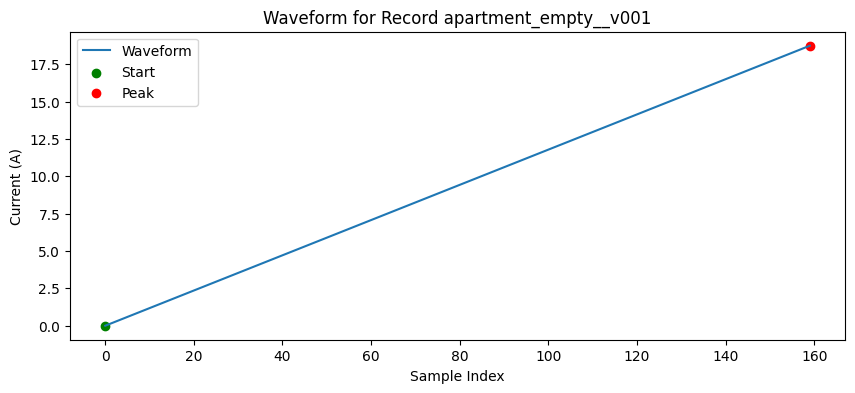

In [6]:
%pip install matplotlib
try:
    import matplotlib.pyplot as plt
    # Robust waveform detection (same as previous cells)
    wf = None
    for key in sample.keys():
        if isinstance(sample[key], list) and all(isinstance(x, (int, float)) for x in sample[key][:5]):
            wf = sample[key]
            print(f"Found waveform in key: {key}")
            break
        if isinstance(sample[key], dict):
            for subkey in sample[key]:
                if isinstance(sample[key][subkey], list) and all(isinstance(x, (int, float)) for x in sample[key][subkey][:5]):
                    wf = sample[key][subkey]
                    print(f"Found waveform in nested key: {key}['{subkey}']")
                    break
            if wf is not None:
                break
    if wf is None:
        raise KeyError("No recognizable waveform key found in sample (even after search)")
    plt.figure(figsize=(10, 4))
    plt.plot(wf, label="Waveform")
    plt.scatter([0], [wf[0]], color="green", label="Start")
    plt.scatter([wf.index(max(wf))], [max(wf)], color="red", label="Peak")
    plt.title(f"Waveform for Record {sample['record_id']}")
    plt.xlabel("Sample Index")
    plt.ylabel("Current (A)")
    plt.legend()
    plt.show()
except ImportError:
    print("matplotlib not installed; skipping plot.")

In [15]:
# Debug: Print available keys and sample structure
print("Top-level keys:", list(sample.keys()))
for k, v in sample.items():
    print(f"{k}: type={type(v)}, example={str(v)[:120]}")

Top-level keys: ['record_id', 'scenario_id', 'variant_role', 'variant_index', 'labels', 'pattern_notes', 'time_s', 'current_a', 'features', 'graph_image']
record_id: type=<class 'str'>, example=apartment_empty__v001
scenario_id: type=<class 'str'>, example=apartment_empty
variant_role: type=<class 'str'>, example=noisy_variant
variant_index: type=<class 'int'>, example=1
labels: type=<class 'dict'>, example={'fill_state': 'empty', 'site_class': 'apartment_communities', 'device_fingerprint': 'wastequip_5yr', 'expected_model_co
pattern_notes: type=<class 'str'>, example=Consistent density, smooth compression, later peak resistance.
time_s: type=<class 'list'>, example=[0.0, 0.1179, 0.2358, 0.3537, 0.4715, 0.5894, 0.7073, 0.8252, 0.9431, 1.061, 1.1788, 1.2967, 1.4146, 1.5325, 1.6504, 1.7
current_a: type=<class 'list'>, example=[13.1433, 13.5096, 14.6072, 13.8203, 13.9872, 13.7207, 13.5643, 13.7722, 14.6851, 15.9594, 18.9201, 23.3736, 27.5266, 30
features: type=<class 'dict'>, example={'du

In [16]:
# Debug: Print available keys and sample structure
print("Top-level keys:", sample.keys())
for k, v in sample.items():
    print(f"{k}: type={type(v)}, example={str(v)[:80]}")

Top-level keys: dict_keys(['record_id', 'scenario_id', 'variant_role', 'variant_index', 'labels', 'pattern_notes', 'time_s', 'current_a', 'features', 'graph_image'])
record_id: type=<class 'str'>, example=apartment_empty__v001
scenario_id: type=<class 'str'>, example=apartment_empty
variant_role: type=<class 'str'>, example=noisy_variant
variant_index: type=<class 'int'>, example=1
labels: type=<class 'dict'>, example={'fill_state': 'empty', 'site_class': 'apartment_communities', 'device_fingerpri
pattern_notes: type=<class 'str'>, example=Consistent density, smooth compression, later peak resistance.
time_s: type=<class 'list'>, example=[0.0, 0.1179, 0.2358, 0.3537, 0.4715, 0.5894, 0.7073, 0.8252, 0.9431, 1.061, 1.1
current_a: type=<class 'list'>, example=[13.1433, 13.5096, 14.6072, 13.8203, 13.9872, 13.7207, 13.5643, 13.7722, 14.6851
features: type=<class 'dict'>, example={'duration_s': 18.7436, 'peak_current_a': 42.1591, 'low_current_a': 0.0, 'mean_c
graph_image: type=<class 'str'>,